# TVS Credit EPIC 8 — Analytics Case Study 2
# Notebook 1 of 2: Data Understanding & Exploratory Analysis

**Runs standalone on Google Colab** — just run all cells and upload the case-study Excel file
when prompted (works equally well locally if the file is in the same folder).

This notebook covers: file upload → data understanding → data quality checks → exploratory
analysis (base composition, disposition, offer amount vs risk, "amount too low" feedback).

The companion notebook, **Notebook 2 — Risk & Offer Logic Model**, is fully self-contained and
picks up from here: it re-loads and re-cleans the data itself, so you can run either notebook
independently, in either order.


## 1. Setup

In [1]:

import sys, warnings
warnings.filterwarnings('ignore')

# Colab-friendly package check (all of these ship pre-installed on Colab; this is just a safety net)
try:
    import openpyxl
except ImportError:
    !pip install -q openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


## 2. Upload & Load Data

Run this cell and select the case-study Excel file (e.g. `EPIC8_Dataset.xlsx`) when the upload
button appears. If you're not running on Colab (e.g. running locally in Jupyter), it will instead
look for the file in the current folder.

In [2]:

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import files
    print("Please upload the case-study Excel file (e.g. EPIC8_Dataset.xlsx)...")
    uploaded = files.upload()
    DATA_PATH = list(uploaded.keys())[0]
    print(f"\nUsing uploaded file: {DATA_PATH}")
else:
    DATA_PATH = "EPIC8_Dataset.xlsx"  # local fallback — keep the file in the same folder as this notebook
    print(f"Not running on Colab — looking for local file: {DATA_PATH}")


Not running on Colab — looking for local file: EPIC8_Dataset.xlsx


In [3]:

df = pd.read_excel(DATA_PATH, sheet_name='Epic_Challenge_Base')
data_dict = pd.read_excel(DATA_PATH, sheet_name='Data_Dictionary')
naming_conv = pd.read_excel(DATA_PATH, sheet_name='Naming_Conventions')

print("Base data shape:", df.shape)
df.head()


Base data shape: (157557, 128)


,SHARED_ID,CATEGORY_NEW,RISK_GRADATION_BNC,RISK_GRADATION_OD,EXTERNAL_CHANNEL_PROPENSITY,INTERNAL_CHANNEL_PROPENSITY,CREDIT_HISTORY_DEPTH_FLAG,AGE,EXTERNAL_RISK_SCORE,EMPLOYMENT_SEGMENT,PRODUCT_SEGMENT,PEAK_PAYMENT_DELAY_IN_13_24_ALL_LOANS,PEAK_PAYMENT_DELAY_IN_7_12_ALL_LOANS,PEAK_PAYMENT_DELAY_IN_1_6_ALL_LOANS,PEAK_PAYMENT_DELAY_ALL_LOANS,PEAK_PAYMENT_DELAY_IN_13_24_PL,PEAK_PAYMENT_DELAY_IN_7_12_PL,PEAK_PAYMENT_DELAY_IN_1_6_PL,PEAK_PAYMENT_DELAY_PL,SUCCESSFUL_PAY_CNT_IN_13_24,SUCCESSFUL_PAY_CNT_IN_7_12,SUCCESSFUL_PAY_CNT_IN_1_6,SUCCESSFUL_PAY_CNT,PAY_CNT_IN_13_24,PAY_CNT_IN_7_12,PAY_CNT_IN_1_6,PAY_CNT,LIVE_SUCCESSFUL_PAY_CNT_IN_13_24,LIVE_SUCCESSFUL_PAY_CNT_IN_7_12,LIVE_SUCCESSFUL_PAY_CNT_IN_1_6,...,MIN_ENQUIRYAMOUNT,AVG_ENQUIRYAMOUNT,MEDIAN_ENQUIRYAMOUNT,TOTAL_ENQUIRYAMOUNT,TOTAL_ENQ_ON_US,TOTAL_PL_ENQ,ENQ_AMT_ON_US,PL_ENQ_AMT,AVG_ENQ_AMT_ON_US,MIN_ENQ_AMT_ON_US,MIN_PL_ENQ_AMT,ENQ_AMT_L6CM,ENQ_AMT_L6_12CM,ENQ_AMT_L12_24CM,PL_ENQ_AMT_L6CM,PL_ENQ_AMT_L6_12CM,PL_ENQ_AMT_L12_24CM,GEO_CAT,RISK_EVENT_RECENT_VINTAGE,RISK_EVENT_LONGER_VINTAGE,EXTERNAL_RISK_EVENT_RECENT_VINTAGE,EXTERNAL_RISK_EVENT_LONGER_VINTAGE,COMPOSITE_RISK_EVENT_RECENT_VINTAGE,COMPOSITE_RISK_EVENT_LONGER_VINATGE,BEST OUTCOME,BEST OUTCOME Remarks,LAST OUTCOME,BASE_TYPE,FINAL_LOAN_AMOUNT,FINAL_LOAN_AMOUNT_BIN
0,FCY2429P,NOT_DISB,6,2,6,10.00,1.00,36.00,727.00,SELF,MC,0.00,-1.00,0.00,24.00,-1.00,-1.00,-1.00,-1.00,2.00,-1.00,16.00,170.00,2.00,-1.00,16.00,171.00,-1.00,-1.00,7.00,...,"4,500,000.00","4,500,000.00","4,500,000.00","4,500,000.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,"4,500,000.00",0.00,0.00,0.00,0.00,0.00,Medium,0,0,0,0,0,0,Not Eligible,Wrong Number,RNR,TEST,100000,1
1,0PTFE86I,NOT_DISB,5,2,9,10.00,1.00,44.00,752.00,SELF,MO,0.00,-1.00,-1.00,0.00,-1.00,-1.00,-1.00,-1.00,4.00,-1.00,-1.00,36.00,4.00,-1.00,-1.00,36.00,-1.00,-1.00,-1.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,High,0,0,0,0,0,0,Not Interested,Not Required by the Customer,RNR,TEST,60000,1
2,COU0OZ2G,NOT_DISB,2,2,1,6.00,1.00,45.00,762.00,SAL,SC,0.00,0.00,0.00,0.00,0.00,-1.00,0.00,0.00,44.00,4.00,21.00,308.00,44.00,4.00,21.00,308.00,-1.00,-1.00,17.00,...,"1,000.00","1,432,808.00","1,000,000.00","18,626,500.00",0.00,7.00,0.00,"9,700,000.00",0.00,0.00,0.00,"65,500.00","60,000.00","8,200,000.00",0.00,0.00,"8,200,000.00",Medium,0,0,0,0,0,0,Not Interested,Not Required by the Customer,Call Dropped,VALIDATION,-1,1
3,711EWEPR,NOT_DISB,7,2,9,10.00,1.00,45.00,757.00,SELF,MC,-1.00,-1.00,17.00,17.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,2.00,70.00,-1.00,-1.00,4.00,72.00,-1.00,-1.00,-1.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Medium,0,0,0,0,0,0,RNR,Ringing No Response,RNR,TEST,100000,1
4,Q1646V0B,ONUS_DISB,6,1,2,2.00,1.00,35.00,721.00,SELF,MC,-1.00,0.00,-1.00,59.00,-1.00,0.00,-1.00,59.00,-1.00,5.00,-1.00,66.00,-1.00,5.00,-1.00,72.00,-1.00,-1.00,-1.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Medium,0,0,0,0,0,0,Appointments,Lead Self Doc Upload,RNR,TEST,120000,2


In [4]:

# Minor cleanup: harmonise a couple of inconsistently-labelled category values
df['EMPLOYMENT_SEGMENT'] = df['EMPLOYMENT_SEGMENT'].replace(
    {'SELF-EMPLOYED': 'SELF', 'SALARIED': 'SAL', 'SENP': 'SEP'}
)
for c in ['EMPLOYMENT_SEGMENT', 'PRODUCT_SEGMENT', 'GEO_CAT']:
    df[c] = df[c].astype('category')

df.dtypes.value_counts()


float64     108
int64        11
str           5
object        1
category      1
category      1
category      1
Name: count, dtype: int64

## 3. Data Understanding

Key fields:

- **`BASE_TYPE`**: `TEST` (has the current/existing offer amount) vs `VALIDATION` (existing offer
  amount withheld — the hold-out set the final logic gets scored on).
- **`FINAL_LOAN_AMOUNT`**: the **current-logic offer amount** (₹40K–₹6L). Present only for `TEST`
  rows; coded `-1` for `VALIDATION` rows.
- **`CATEGORY_NEW`**: `NOT_DISB` (offer made, no loan taken), `ONUS_DISB` (took the loan), `OFFUS_DISB`
  (took a competing loan instead).
- **`RISK_EVENT_RECENT_VINTAGE`**: 30+ DPD within the first 6 months on book — only meaningful for
  `ONUS_DISB` customers. This is the "**% Ever 30 in MOB 1-6**" metric required in the final deliverable.
- **`BEST OUTCOME` / `LAST OUTCOME` / `BEST OUTCOME Remarks`**: customer disposition. The
  "Amount too low" feedback shows up as the remark `Require Higher Loan Amount`.
- 100+ bureau/behavioural features covering risk gradations, EMI/exposure, enquiry, and repayment history.


In [5]:

print("BASE_TYPE counts:")
print(df['BASE_TYPE'].value_counts(), "\n")

print("CATEGORY_NEW counts:")
print(df['CATEGORY_NEW'].value_counts(), "\n")

print("FINAL_LOAN_AMOUNT is -1 (withheld) exactly for Validation rows:")
print(pd.crosstab(df['FINAL_LOAN_AMOUNT'] == -1, df['BASE_TYPE']))


BASE_TYPE counts:
BASE_TYPE
TEST          119989
VALIDATION     37568
Name: count, dtype: int64 

CATEGORY_NEW counts:
CATEGORY_NEW
NOT_DISB      129078
ONUS_DISB      21824
OFFUS_DISB      6655
Name: count, dtype: int64 

FINAL_LOAN_AMOUNT is -1 (withheld) exactly for Validation rows:
BASE_TYPE            TEST  VALIDATION
FINAL_LOAN_AMOUNT                    
False              119989           0
True                    0       37568


In [6]:

# Derive the "Amount too low" disposition flag from the remarks field
df['AMOUNT_TOO_LOW_FLAG'] = (
    df['BEST OUTCOME Remarks'].astype(str)
      .str.contains('Higher Loan Amount', case=False, na=False)
      .astype(int)
)

print("Customers who said the offered amount was too low:", df['AMOUNT_TOO_LOW_FLAG'].sum(),
      f"({df['AMOUNT_TOO_LOW_FLAG'].mean()*100:.2f}% of base)")

# RISK_EVENT_RECENT_VINTAGE is only ever 1 for ONUS_DISB customers (repayment performance is
# only observable for loans we actually disbursed)
pd.crosstab(df['CATEGORY_NEW'], df['RISK_EVENT_RECENT_VINTAGE'])


Customers who said the offered amount was too low: 808 (0.51% of base)


RISK_EVENT_RECENT_VINTAGE,0,1
CATEGORY_NEW,,
NOT_DISB,129078,0
OFFUS_DISB,6655,0
ONUS_DISB,21536,288


## 4. Data Quality Checks

114 of 129 columns have missing values (max = 7.20%)


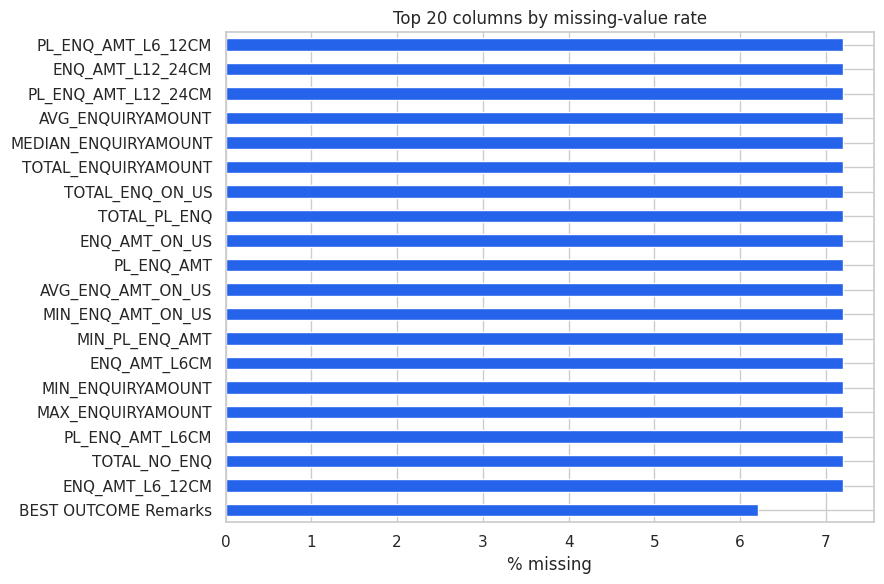

In [7]:

missing = df.isna().mean().sort_values(ascending=False) * 100
missing = missing[missing > 0]
print(f"{len(missing)} of {df.shape[1]} columns have missing values (max = {missing.max():.2f}%)")

fig, ax = plt.subplots(figsize=(9, 6))
missing.head(20).plot(kind='barh', ax=ax, color='#2563eb')
ax.invert_yaxis()
ax.set_xlabel('% missing')
ax.set_title('Top 20 columns by missing-value rate')
plt.tight_layout()
plt.show()


In [8]:

# Sentinel-value check: several bureau fields use -1 / 999 as "no data" codes rather than NaN
sentinel_cols = ['PEAK_PAYMENT_DELAY_ALL_LOANS', 'PEAK_PAYMENT_DELAY_PL',
                  'SUCCESSFUL_PAY_CNT_IN_1_6', 'PAY_CNT_IN_1_6']
for c in sentinel_cols:
    print(c, '-> -1 count:', (df[c] == -1).sum(), '| 999 count:', (df[c] == 999).sum())
print("\nThese are treated as legitimate categorical/sentinel signals (tree-based models handle "
      "them natively without imputation) in Notebook 2.")


PEAK_PAYMENT_DELAY_ALL_LOANS -> -1 count: 0 | 999 count: 3834
PEAK_PAYMENT_DELAY_PL -> -1 count: 112753 | 999 count: 258
SUCCESSFUL_PAY_CNT_IN_1_6 -> -1 count: 19356 | 999 count: 0
PAY_CNT_IN_1_6 -> -1 count: 19356 | 999 count: 0

These are treated as legitimate categorical/sentinel signals (tree-based models handle them natively without imputation) in Notebook 2.


## 5. Exploratory Data Analysis

### 5.1 Base composition

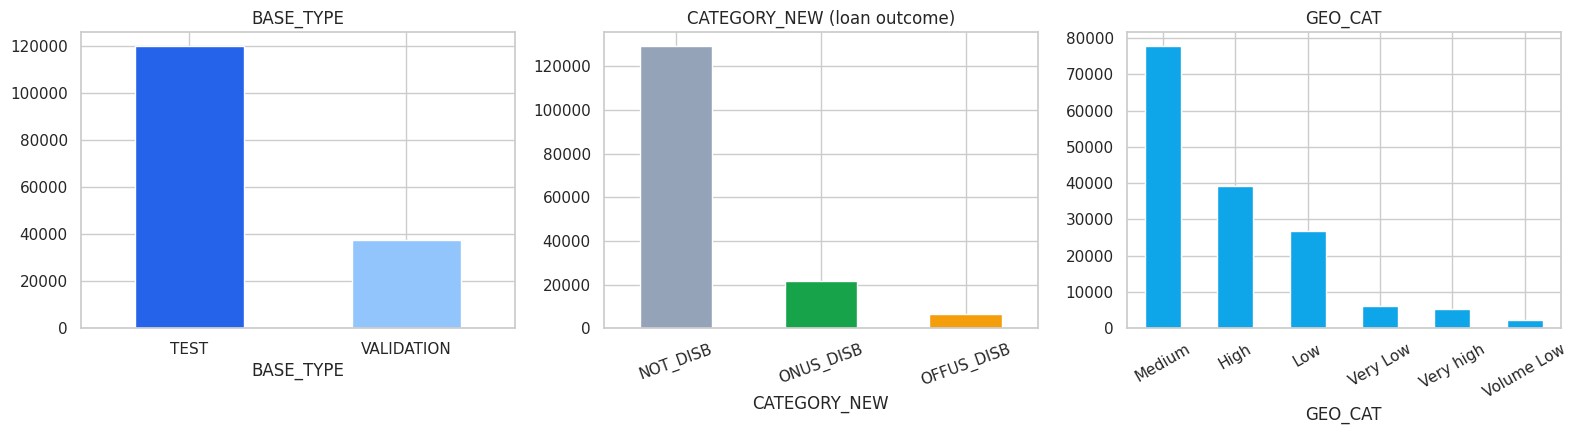

Personal-loan take-up rate (ONUS_DISB) among all contacted customers: 13.85%
Customers who switched to a competitor loan instead (OFFUS_DISB): 4.22%


In [9]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

df['BASE_TYPE'].value_counts().plot(kind='bar', ax=axes[0], color=['#2563eb', '#93c5fd'])
axes[0].set_title('BASE_TYPE'); axes[0].tick_params(axis='x', rotation=0)

df['CATEGORY_NEW'].value_counts().plot(kind='bar', ax=axes[1], color=['#94a3b8', '#16a34a', '#f59e0b'])
axes[1].set_title('CATEGORY_NEW (loan outcome)'); axes[1].tick_params(axis='x', rotation=20)

df['GEO_CAT'].value_counts().plot(kind='bar', ax=axes[2], color='#0ea5e9')
axes[2].set_title('GEO_CAT'); axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()

print("Personal-loan take-up rate (ONUS_DISB) among all contacted customers:",
      f"{(df['CATEGORY_NEW']=='ONUS_DISB').mean()*100:.2f}%")
print("Customers who switched to a competitor loan instead (OFFUS_DISB):",
      f"{(df['CATEGORY_NEW']=='OFFUS_DISB').mean()*100:.2f}%")


### 5.2 Demographics

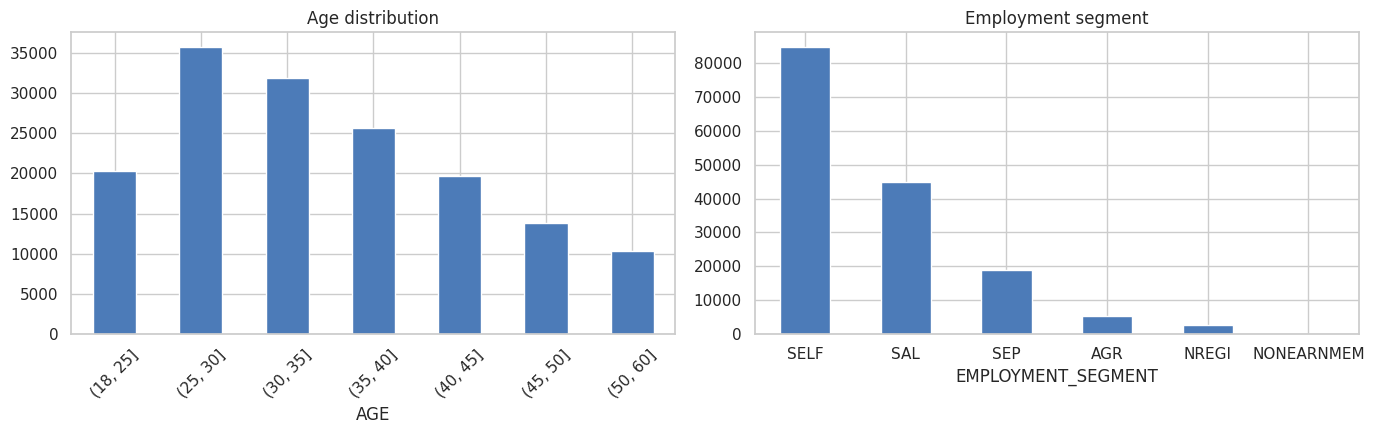

In [10]:

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

age_bins = pd.cut(df['AGE'], bins=[18,25,30,35,40,45,50,60,100])
df.groupby(age_bins, observed=True).size().plot(kind='bar', ax=axes[0], color='#4C7BB8')
axes[0].set_title('Age distribution'); axes[0].tick_params(axis='x', rotation=45)

df['EMPLOYMENT_SEGMENT'].value_counts().plot(kind='bar', ax=axes[1], color='#4C7BB8')
axes[1].set_title('Employment segment'); axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout(); plt.show()


### 5.3 Disposition / customer feedback

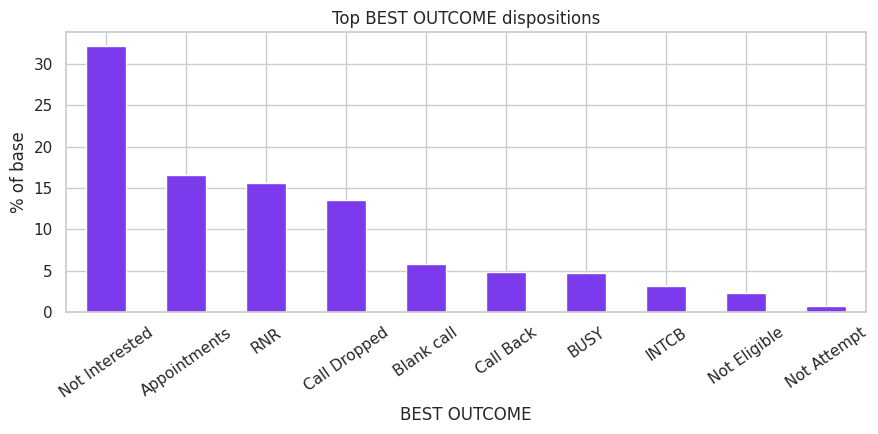

'Require Higher Loan Amount' (amount too low) feedback: 0.51% of base, 0.61% of customers who did not take the loan.


In [11]:

disp = df['BEST OUTCOME'].value_counts(normalize=True).head(10) * 100
fig, ax = plt.subplots(figsize=(9, 4.5))
disp.plot(kind='bar', ax=ax, color='#7c3aed')
ax.set_ylabel('% of base'); ax.set_title('Top BEST OUTCOME dispositions')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout(); plt.show()

print(f"'Require Higher Loan Amount' (amount too low) feedback: "
      f"{df['AMOUNT_TOO_LOW_FLAG'].mean()*100:.2f}% of base, "
      f"{df.loc[df['CATEGORY_NEW']=='NOT_DISB','AMOUNT_TOO_LOW_FLAG'].mean()*100:.2f}% "
      f"of customers who did not take the loan.")


### 5.4 Existing offer amount vs risk

Does the *current* offer logic already offer less to riskier customers? We use
`RISK_GRADATION_OD` / `RISK_GRADATION_BNC` (bureau-based risk bands — higher band = higher risk)
and `EXTERNAL_RISK_SCORE` (continuous bureau score, higher = safer) as model-free, independent
views of risk.

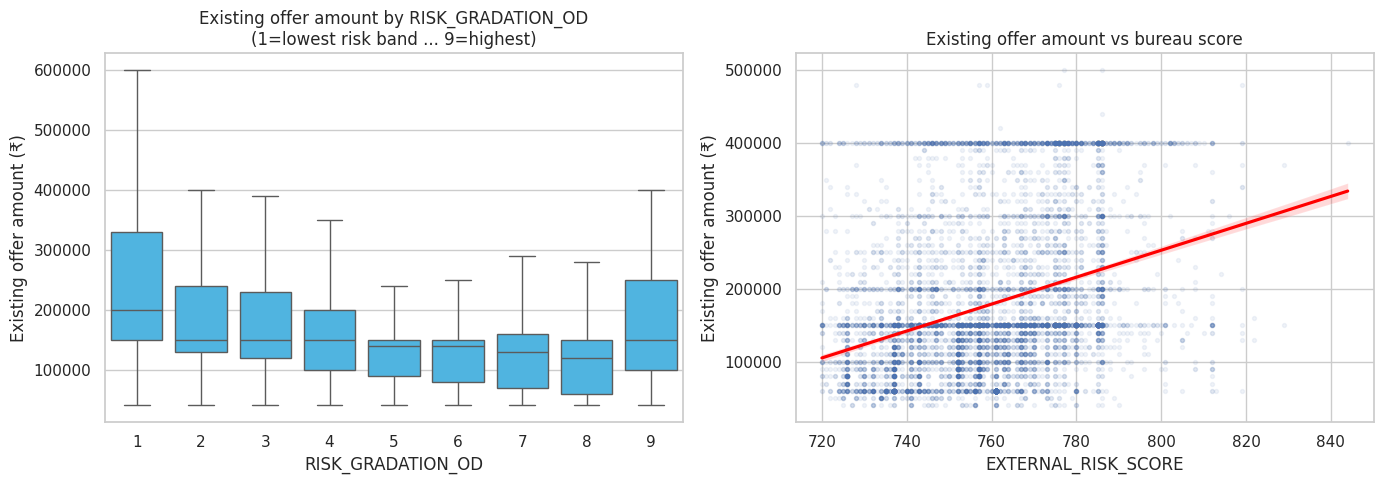

In [12]:

test_df = df[df['BASE_TYPE'] == 'TEST'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=test_df, x='RISK_GRADATION_OD', y='FINAL_LOAN_AMOUNT', ax=axes[0],
            color='#38bdf8', showfliers=False)
axes[0].set_title('Existing offer amount by RISK_GRADATION_OD\n(1=lowest risk band ... 9=highest)')
axes[0].set_ylabel('Existing offer amount (₹)')

sns.regplot(data=test_df.sample(min(8000, len(test_df)), random_state=42), x='EXTERNAL_RISK_SCORE',
            y='FINAL_LOAN_AMOUNT', ax=axes[1], scatter_kws={'alpha': 0.08, 's': 8},
            line_kws={'color': 'red'})
axes[1].set_title('Existing offer amount vs bureau score')
axes[1].set_ylabel('Existing offer amount (₹)')

plt.tight_layout(); plt.show()


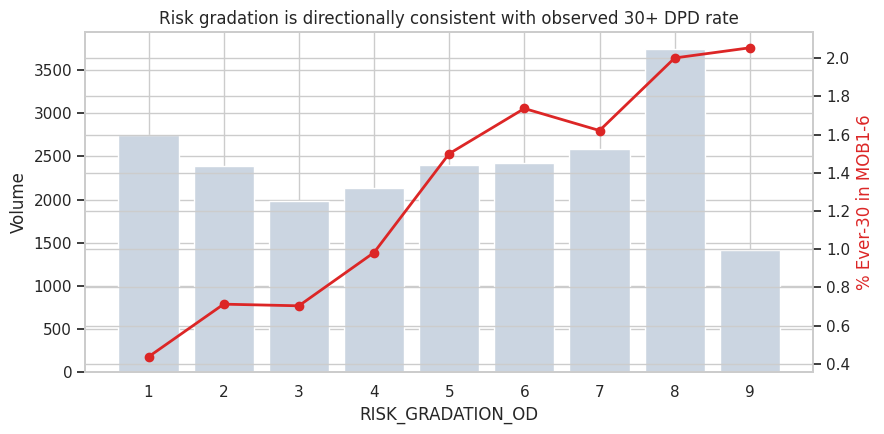

,% Ever-30 in MOB1-6,Volume
RISK_GRADATION_OD,,
1,0.44,2743
2,0.71,2385
3,0.70,1988
4,0.98,2137
5,1.50,2400
6,1.74,2419
7,1.62,2591
8,2.00,3749
9,2.05,1412


In [13]:

# Does risk gradation actually predict the 30+ DPD outcome? (sanity check on ONUS_DISB)
onus = df[df['CATEGORY_NEW'] == 'ONUS_DISB']
risk_rate_by_grade = onus.groupby('RISK_GRADATION_OD', observed=True)['RISK_EVENT_RECENT_VINTAGE'].agg(['mean', 'count'])
risk_rate_by_grade['mean'] *= 100
risk_rate_by_grade.columns = ['% Ever-30 in MOB1-6', 'Volume']

fig, ax1 = plt.subplots(figsize=(9, 4.5))
x = risk_rate_by_grade.index.astype(str)
ax1.bar(x, risk_rate_by_grade['Volume'], color='#cbd5e1', label='Volume')
ax1.set_ylabel('Volume'); ax1.set_xlabel('RISK_GRADATION_OD')
ax2 = ax1.twinx()
ax2.plot(x, risk_rate_by_grade['% Ever-30 in MOB1-6'], color='#dc2626', marker='o', linewidth=2,
         label='% Ever-30 MOB1-6')
ax2.set_ylabel('% Ever-30 in MOB1-6', color='#dc2626')
ax1.set_title('Risk gradation is directionally consistent with observed 30+ DPD rate')
fig.tight_layout(); plt.show()

risk_rate_by_grade


### 5.5 Existing offer amount by loan-outcome segment

Does the "amount not sufficient" complaint relate to how much customers were actually offered?

              Avg offer (₹)  Median offer (₹)  Volume
CATEGORY_NEW                                         
NOT_DISB         176,665.68        150,000.00   98302
OFFUS_DISB       222,151.60        170,000.00    5066
ONUS_DISB        173,553.94        150,000.00   16621


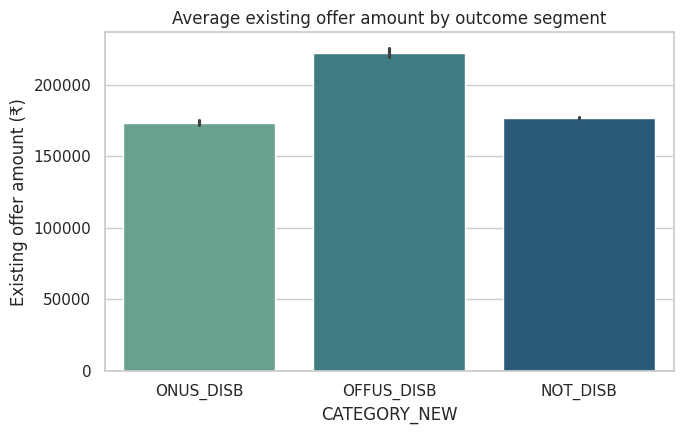

In [14]:

seg_avg = test_df.groupby('CATEGORY_NEW', observed=True)['FINAL_LOAN_AMOUNT'].agg(['mean', 'median', 'count'])
seg_avg.columns = ['Avg offer (₹)', 'Median offer (₹)', 'Volume']
print(seg_avg)

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(data=test_df, x='CATEGORY_NEW', y='FINAL_LOAN_AMOUNT', ax=ax,
            order=['ONUS_DISB', 'OFFUS_DISB', 'NOT_DISB'], errorbar=('ci', 95), palette='crest')
ax.set_title('Average existing offer amount by outcome segment')
ax.set_ylabel('Existing offer amount (₹)')
plt.tight_layout(); plt.show()


In [15]:

low_amt_rate_by_bin = test_df.groupby('FINAL_LOAN_AMOUNT_BIN', observed=True)['AMOUNT_TOO_LOW_FLAG'].mean() * 100
print("'Amount too low' complaint rate by existing-offer quartile bin:")
print(low_amt_rate_by_bin)
print("\n=> Customers offered smaller amounts are more likely to say the amount is insufficient — "
      "this is the pain point the offer logic in Notebook 2 needs to address, without loosening "
      "risk discipline.")


'Amount too low' complaint rate by existing-offer quartile bin:
FINAL_LOAN_AMOUNT_BIN
1   0.61
2   0.54
3   0.48
4   0.43
Name: AMOUNT_TOO_LOW_FLAG, dtype: float64

=> Customers offered smaller amounts are more likely to say the amount is insufficient — this is the pain point the offer logic in Notebook 2 needs to address, without loosening risk discipline.


## 6. Summary — What This Tells Us

- The current offer logic is **already broadly risk-aware**: average offer amount rises with
  bureau risk grade, and observed 30+ DPD rate rises with risk grade too — the signals are directionally
  consistent.
- **"Amount too low" is a real and sizeable drop-off reason**, concentrated among customers offered
  smaller amounts — this is the specific pain point a new offer logic should target.
- Customers who take a **competitor loan instead** (`OFFUS_DISB`) were, on average, offered *more*
  than customers who stayed with us — worth keeping in mind when calibrating any new logic so it
  doesn't inadvertently offer this segment less.
- Data quality is solid for modelling purposes: missingness is concentrated in a handful of bureau
  fields, and several "-1"/"999" sentinel codes are legitimate categorical signals rather than
  true missing values.

**Continue to Notebook 2** for the risk model, capacity model, offer-amount logic, evaluation
metric, and the final validation deliverable.
